# Simulator Benchmark: GRN Differentiation Gradient

Benchmarks three single-cell RNA-seq simulators — **SERGIO**, **qSimCells**, and
**scMultiSim** — against a controlled ground-truth gene regulatory network (GRN).

## Experimental design

A single cell type (TypeA) is simulated at **4 regulatory strengths** (pseudo-timepoints
t1 → t4), producing a differentiation-like gradient. Concatenating all 2,000 cells per
simulator reveals a PHATE/UMAP pseudotime axis driven solely by GRN interaction strength.

| Property | Value |
|----------|-------|
| Cells per level | 500 |
| GRN levels | 4 (t1–t4) |
| Total cells per simulator | 2,000 |
| GRN genes | 5 (G0–G4) |
| Housekeeping genes | 50 (HKG_0 – HKG_49) |
| Total genes per matrix | 55 |
| Random seed | 42 |

## Ground-truth GRN

```
G0 → G1 → G2 → G3       (linear activating cascade)
G4                        (independent control — no regulatory edges)
```

G0 is the **master regulator**: constitutively active in all three simulators.
Its low cell-to-cell variance is a design feature (not a bug) — it tests whether
GRN inference can recover edges from a near-constant upstream regulator.

## GRN strength parameterisation per simulator

| Simulator | GRN parameter | t1 | t2 | t3 | t4 |
|-----------|---------------|----|----|----|----|
| SERGIO | Hill k (interaction amplitude) | 0.01 | 0.2 | 2.0 | 20.0 |
| qSimCells | CRX angle λ (×π) | 0.1π | 0.4π | 0.7π | 1.0π |
| scMultiSim | edge `effect` weight | 0.001 | 0.20 | 1.00 | 3.00 |

Higher values = stronger GRN cascade in all simulators.


## 0  Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scanpy as sc
import anndata as ad
import warnings, os, sys, subprocess
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import nbinom, ks_2samp, pearsonr, spearmanr
from scipy.optimize import minimize
from scipy.special import digamma

# ── Dask / arboreto (before qiskit to avoid multiprocessing conflicts) ────────
import dask.dataframe as dd
import arboreto.core as ac
from arboreto.algo import grnboost2, genie3

# Patch: prevents empty-partition crash in arboreto with newer Dask.
# No Client() — avoids Windows kernel crash (0xC0000409) from distributed+Qiskit.
if not hasattr(ac, '_original_from_delayed'):
    ac._original_from_delayed = ac.from_delayed

def _patched_from_delayed(dfs, *args, **kwargs):
    if not dfs or len(dfs) == 0:
        meta = kwargs.get('meta', None)
        if isinstance(meta, pd.DataFrame):
            return dd.from_pandas(meta, npartitions=1)
        return dd.from_pandas(pd.DataFrame(), npartitions=1)
    return ac._original_from_delayed(dfs, *args, **kwargs)

ac.from_delayed = _patched_from_delayed

# ── qSimCells / Qiskit ────────────────────────────────────────────────────────
# qsim_cells package lives in current directory
REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
from qsim_cells.generative import (
    create_rotation_circuit,
    concatenate_circuits_with_separate_measurements,
    add_crx_and_measurements_to_circuit,
    create_binary_matrix,
    create_count_matrix_nbinom,
)
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

print("All imports OK.")

All imports OK.


## 1  Shared scenario parameters

Defines all parameters shared across the three simulators. All downstream cells
read from these variables — do **not** hardcode values elsewhere.

**Critical design choices:**

- `N_CELLS = 500` per GRN level, matching qSimCells shot budget and SERGIO/scMultiSim
  run cost. 2,000 total cells per simulator provides sufficient neighbourhood coverage
  for UMAP/PHATE and stable GENIE3 estimates.
- `GT_EDGES = [(0,1),(1,2),(2,3)]` — 3 directed activating edges; 17 non-edges. AUROC
  baseline = 0.5 (random); perfect = 1.0.
- `MU_VEC` / `R_VEC` — NB augmentation parameters define the expected expression
  magnitude for each GRN gene after sampling from the simulator's native output.
  G0 (MU_VEC[0]=50) is highest; G1–G3 decrease through the cascade; G4 (MU_VEC[4]=20)
  is an independent control.
- `SERGIO_K` keys map t1→t4 to Hill k values. High k = strong activation (not weak).
- `ANGLES_A` encodes qSimCells G0 at 0.70π ≈ 79% ON. Previously 0.90π (97.5%) was
  too constitutive — near-zero variance prevented any GENIE3 signal on G0→G1.
- `SCM_EFFECT` maps t1→t4 to scMultiSim edge weights. t4=3.00 is the maximum tested.
  Strong cascade at t4=3.0 produces the clearest GRN gradient across all levels.


In [2]:
# ── Gene / circuit layout ──────────────────────────────────────────────────
N_GENES  = 5          # qubits / simulated genes
N_CELLS  = 500        # cells per GRN-strength level
SEED     = 42
rng      = np.random.default_rng(SEED)

GENE_NAMES = [f"G{i}" for i in range(N_GENES)]

# ── Ground-truth directed GRN ──────────────────────────────────────────────
GT_EDGES = [(0, 1), (1, 2), (2, 3)]
GT_ADJ   = np.zeros((N_GENES, N_GENES))
for (r, t) in GT_EDGES:
    GT_ADJ[r, t] = 1.0

# ── NB augmentation params ────────────────────────────────────────────────
MU_VEC = np.array([50., 40., 35., 30., 20.])
R_VEC  = np.array([ 5.,  5.,  5.,  5.,  8.])

# ── Single cell-type angles ───────────────────────────────────────────────
# G0 = 0.90π (driver, always ON ~97 %)
# G1-G3 = 0.15π (downstream, OFF at baseline ~2 %)
# G4 = 0.35π (independent control ~27 %)
# With CRX(π): G0=|1⟩ flips G1 from OFF → ON  (activating cascade)
# With CRX(0.1π): G0 barely perturbs G1  (near-independent)
ANGLES_A = np.array([0.70, 0.15, 0.15, 0.15, 0.35]) * np.pi
INTERACTION_MAP = [(0, 1), (1, 2), (2, 3)]  # cascade entanglement

# ── GRN gradient levels (pseudo-timepoints t1 → t4) ──────────────────────
GRN_LEVELS = ["t1", "t2", "t3", "t4"]

# qSimCells CRX angles (λ)
CRX_ANGLES = {"t1": 0.10*np.pi, "t2": 0.40*np.pi,
              "t3": 0.70*np.pi, "t4": 1.00*np.pi}

# SERGIO Hill cooperativity exponent k (higher k = steeper activation when G0 > K_half)
# t1 = near-OFF cascade, t4 = near-fully-ON cascade
SERGIO_K   = {"t1": 0.01, "t2": 0.2, "t3": 2.0, "t4": 20.0}  # k = interaction effect; HIGH k = STRONG cascade

# scMultiSim GRN edge effect weights
SCM_EFFECT = {"t1": 0.001, "t2": 0.20, "t3": 1.00, "t4": 3.00}

# Display labels and colormap
GRN_DISP   = {"t1": "10%", "t2": "40%",
               "t3": "70%", "t4": "100%"}
GRN_COLORS = {"t1": "#A8D8EA", "t2": "#57B8D4",
               "t3": "#1E7EAB", "t4": "#0A3D62"}

# ── Housekeeping genes ────────────────────────────────────────────────────
N_HKG     = 50
MU_HKG    = np.full(N_HKG, 80.)
R_HKG     = np.full(N_HKG, 6.)
HKG_NAMES = [f"HKG_{i}" for i in range(N_HKG)]
ALL_GENES = GENE_NAMES + HKG_NAMES   # 55 total

COLORS_SIM = {"SERGIO": "#4CAF50", "qSimCells": "#9C27B0", "scMultiSim": "#FF9800"}

print(f"GT edges: {GT_EDGES}")
print(f"GRN levels: {GRN_LEVELS}")
print(f"CRX angles: { {k: f'{v/np.pi:.2f}π' for k,v in CRX_ANGLES.items()} }")
# ── Plot axis helpers (used across all cells) ─────────────────────────────
level_x   = np.arange(len(GRN_LEVELS))
level_xtk = [GRN_DISP[t] for t in GRN_LEVELS]

# ── Display constants ─────────────────────────────────────────────────────
GENE_COLS  = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']


GT edges: [(0, 1), (1, 2), (2, 3)]
GRN levels: ['t1', 't2', 't3', 't4']
CRX angles: {'t1': '0.10π', 't2': '0.40π', 't3': '0.70π', 't4': '1.00π'}


## 2  SERGIO simulation

SERGIO (Dibaeinia & Sinha, *Cell Systems* 2020) simulates gene expression using
**Langevin stochastic differential equations (SDE)**:

    dXᵢ/dt = prodᵢ(X) − λ·Xᵢ + σ·ξ(t)

- **Xᵢ** — mRNA abundance of gene i  
- **prodᵢ(X)** — production rate: fixed basal rate for master regulators,  
  or a sum of Hill functions from upstream regulators for target genes  
- **λ·Xᵢ** — constant mRNA decay  
- **σ·ξ(t)** — Gaussian noise (biological stochasticity; `noise_s=0.5`)

**GRN gradient parameterisation:**  
Each edge uses `add_interaction(reg, tar, k, h=2.0, n=1)` where **k is the Hill cooperativity exponent** (steepness of activation):
- t1 k=0.1 → very shallow Hill → G1 barely activated (~3 counts)
- t4 k=10  → steep Hill       → G1 strongly activated (~170 counts)

Technical noise (DS8) is **not** applied; instead the continuous steady-state expression is
scaled to `MU_VEC[0]=50` and converted to integer counts via NB sampling, matching the
augmentation used by qSimCells and scMultiSim.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Import sergio_rs  (pip install sergio_rs — official PyPI package)
# ─────────────────────────────────────────────────────────────────────────────
import polars as pl   # sergio_rs returns polars DataFrames

try:
    import sergio_rs
    SERGIO_AVAILABLE = True
    print(f"sergio_rs loaded OK (Rust rewrite of SERGIO v2, ~150x faster).")
except ImportError:
    SERGIO_AVAILABLE = False
    print("sergio_rs not found — using inline Langevin SDE fallback.")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Define genes and GRN
# ─────────────────────────────────────────────────────────────────────────────
# sergio_rs API:
#   Gene(name: str, decay: float)
#   GRN.add_interaction(reg: Gene, tar: Gene, k: float, h: float, n: int)
#     k = activation threshold (Hill half-max)
#     h = Hill coefficient (cooperativity; higher = more switch-like)
#     n = number of binding sites (int; use 1 for standard activation)
#   GRN.set_mrs()   auto-detects master regulators (genes with no incoming edges)
#
# Note: sergio_rs simulates only genes that appear in add_interaction calls.
# G4 (independent control gene) is not in any interaction, so it is added
# post-hoc as independent Poisson noise to complete the 5-gene panel.

if SERGIO_AVAILABLE:
    # Define genes: name must match across Gene() and add_interaction() calls
    _g0 = sergio_rs.Gene("G0", 0.8)   # master regulator (cascade driver)
    _g1 = sergio_rs.Gene("G1", 0.8)   # cascade: G0 → G1
    _g2 = sergio_rs.Gene("G2", 0.8)   # cascade: G1 → G2
    _g3 = sergio_rs.Gene("G3", 0.8)   # cascade: G2 → G3

    _grn = sergio_rs.GRN()
    _grn.add_interaction(_g0, _g1, 1.5, 2.0, 1)   # G0 → G1, Hill k=1.5 h=2
    _grn.add_interaction(_g1, _g2, 1.5, 2.0, 1)   # G1 → G2
    _grn.add_interaction(_g2, _g3, 1.5, 2.0, 1)   # G2 → G3
    _grn.set_mrs()  # marks G0 as master regulator (only gene with no upstream)

    print("GRN defined: G0 → G1 → G2 → G3 (cascade), G4 added post-hoc")

sergio_rs loaded OK (Rust rewrite of SERGIO v2, ~150x faster).
GRN defined: G0 → G1 → G2 → G3 (cascade), G4 added post-hoc


In [4]:
# SERGIO — 4 GRN strength levels
# k is the Hill cooperativity exponent; higher k = steeper sigmoidal, more activation.
# Use n_types=2 (MrProfile requires non-overlapping ranges); TypeA = high-G0 half.
# No DS8 noise — apply NB augmentation directly on scaled continuous expression
# so counts are comparable to qSimCells/scMultiSim in the same units (MU_VEC scale).

counts_sergio = {}   # {level: (N_CELLS, N_GENES) int32}

if SERGIO_AVAILABLE:
    _rng_nb = np.random.default_rng(SEED + 200)

    for level in GRN_LEVELS:
        k_val = SERGIO_K[level]

        _g0 = sergio_rs.Gene("G0", 0.8)
        _g1 = sergio_rs.Gene("G1", 0.8)
        _g2 = sergio_rs.Gene("G2", 0.8)
        _g3 = sergio_rs.Gene("G3", 0.8)

        _grn = sergio_rs.GRN()
        _grn.add_interaction(_g0, _g1, k_val, 2.0, 1)
        _grn.add_interaction(_g1, _g2, k_val, 2.0, 1)
        _grn.add_interaction(_g2, _g3, k_val, 2.0, 1)
        _grn.set_mrs()

        # Two cell types required by MrProfile; TypeA = high-basal (1.80–2.80)
        _mr  = sergio_rs.MrProfile.from_random(_grn, 2, (0.08, 0.20), (1.20, 1.80), SEED)
        _sim = sergio_rs.Sim(_grn, N_CELLS, 1, 15, 0.01, 0.5, SEED)   # noise_s=0.5
        _df  = _sim.simulate(_mr)

        _arr  = _df.drop("Genes").to_numpy().T   # (2*N_CELLS, 4)
        # TypeA = whichever half has higher G0 mean
        _g0_t0 = _arr[:N_CELLS, 0].mean()
        _g0_t1 = _arr[N_CELLS:, 0].mean()
        _typeA = _arr[:N_CELLS] if _g0_t0 > _g0_t1 else _arr[N_CELLS:]  # (N_CELLS, 4)

        # Scale so G0 mean matches MU_VEC[0], then NB-sample each gene
        # No rescaling — use SERGIO native SDE units directly
        _mu_raw  = _typeA.clip(1e-3)          # raw SDE means
        _counts4 = np.zeros((N_CELLS, 4), dtype=np.int32)
        for gi in range(4):
            mu_g = _mu_raw[:, gi]
            r_g  = R_VEC[gi]
            p_g  = r_g / (r_g + mu_g)
            _counts4[:, gi] = _rng_nb.negative_binomial(r_g, p_g).astype(np.int32)

        # G4 independent housekeeping (Poisson)
        _g4_col = _rng_nb.poisson(1, size=(N_CELLS, 1)).astype(np.int32)
        counts_sergio[level] = np.hstack([_counts4, _g4_col])

        g0_m = counts_sergio[level][:, 0].mean()
        g1_m = counts_sergio[level][:, 1].mean()
        print(f"  SERGIO {level} (k={k_val:>5.2f}): G0={g0_m:.1f}  G1={g1_m:.1f}")

else:
    # Fallback: independent NB with increasing downstream mean
    for i, level in enumerate(GRN_LEVELS):
        frac = [0.05, 0.20, 0.55, 0.90][i]
        _rng2 = np.random.default_rng(SEED + i)
        m = np.array([MU_VEC[0], MU_VEC[1]*frac, MU_VEC[2]*frac,
                      MU_VEC[3]*frac, MU_VEC[4]])
        p = R_VEC / (R_VEC + m)
        counts_sergio[level] = _rng2.negative_binomial(
            R_VEC.astype(int), p, size=(N_CELLS, N_GENES)).astype(np.int32)
    print("SERGIO: using NB fallback (sergio_rs not available)")

print(f"\nSERGIO counts shapes: { {k: v.shape for k,v in counts_sergio.items()} }")


  SERGIO t1 (k= 0.01): G0=1.6  G1=0.1
  SERGIO t2 (k= 0.20): G0=1.8  G1=0.3
  SERGIO t3 (k= 2.00): G0=1.7  G1=1.8
  SERGIO t4 (k=20.00): G0=1.8  G1=16.6

SERGIO counts shapes: {'t1': (500, 5), 't2': (500, 5), 't3': (500, 5), 't4': (500, 5)}


## 3  qSimCells simulation

Uses the PQC from `generative.py`:
- **Ry(θ)** on each qubit encodes gene activation probability  
- **CX cascade** (G0→G1→G2→G3) encodes regulatory dependency  
- **NB augmentation** adds overdispersed counts  

Two cell types share the same circuit architecture with different Ry angles.

In [5]:
# qSimCells — 4 CRX angle levels
# All runs use ANGLES_A (same base expression).
# GRN strength = CRX angle λ; λ=0 means no entanglement, λ=π means full CX.

def run_qsimcells_single(angles, crx_angle, n_shots, mu_vec, r_vec,
                          interaction_map, seed):
    """Single-type qSimCells run. Returns (N_CELLS, N_GENES) int32 array."""
    backend = AerSimulator(seed_simulator=seed)
    circ    = create_rotation_circuit(angles)
    # Dummy second circuit (same angles) for the concatenation API;
    # we only use measurement register 1
    combined = concatenate_circuits_with_separate_measurements(circ, circ)
    circuit  = add_crx_and_measurements_to_circuit(
        combined, circ1_num_qubits=len(angles),
        interaction_map=interaction_map, crx_angle=crx_angle)

    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    pm  = generate_preset_pass_manager(backend=backend, optimization_level=1)
    qc  = pm.run(circuit)
    job = Sampler(mode=backend).run([qc], shots=n_shots)
    res = job.result()[0]

    bin_a = create_binary_matrix(res.data.c_measure1.get_counts())
    np.random.seed(seed)
    return create_count_matrix_nbinom(bin_a, mu_vec, r_vec)

counts_qsim = {}

for level in GRN_LEVELS:
    lam = CRX_ANGLES[level]
    cnt = run_qsimcells_single(
        ANGLES_A, lam, N_CELLS,
        MU_VEC, R_VEC, INTERACTION_MAP, SEED)
    counts_qsim[level] = cnt
    g0_m = cnt[:, 0].mean()
    g1_m = cnt[:, 1].mean()
    print(f"  qSimCells {level} (λ={lam/np.pi:.2f}π): G0={g0_m:.1f}  G1={g1_m:.1f}")

print(f"\nqSimCells counts shapes: { {k: v.shape for k,v in counts_qsim.items()} }")

  qSimCells t1 (λ=0.10π): G0=39.9  G1=4.2
  qSimCells t2 (λ=0.40π): G0=40.6  G1=14.1
  qSimCells t3 (λ=0.70π): G0=39.9  G1=25.9
  qSimCells t4 (λ=1.00π): G0=39.5  G1=30.5

qSimCells counts shapes: {'t1': (500, 5), 't2': (500, 5), 't3': (500, 5), 't4': (500, 5)}


## 4  scMultiSim simulation

scMultiSim (Zhang et al. 2023) uses **Cell Identity Factors (CIFs)** — latent
variables that capture cell-type identity — combined with a kinetic model (burst
frequency × burst size) to generate counts.  Gene expression is driven by the GRN
through how CIFs are propagated along a cell-type phylogenetic tree.

**Install** (once, inside R):
```r
install.packages("remotes")
remotes::install_github("ZhangLabGT/scMultiSim")
```

The notebook calls `scmultisim_benchmark.R` via `Rscript`.  Run the **R path setup cell** below if Rscript is not on your system PATH.

In [6]:
# ── Windows: add Rscript to PATH if not already found ────────────────────────
# Adjust r_bin_path if your R installation is in a different location.

import os, shutil

r_bin_path = r"C:\Program Files\R\R-4.5.2\bin\x64"
if r_bin_path not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + r_bin_path

# Tell R where your user package library is
os.environ["R_LIBS_USER"] = r"C:\Users\selim\AppData\Local\R\win-library\4.5"

rscript_path = shutil.which("Rscript")
if rscript_path:
    print(f"Rscript found at: {rscript_path}")
else:
    print("WARNING: Rscript not found. Install R or update r_bin_path above.")


Rscript found at: C:\Program Files\R\R-4.5.2\bin\x64\Rscript.EXE


## 4b  Run scMultiSim (Rscript)

Calls `scmultisim_benchmark.R` once per GRN level, outputting a sparse MTX matrix.

**Key R parameters:**
- `cif.mean = 1.5` — low CIF baseline so the GRN edge coupling is the primary driver of
  expression variance. At `cif.mean = 4.0` (the previous value) the latent CIF baseline
  dwarfed the GRN signal: G1 log1p only changed 4.50→4.65 across all levels (0.15 units).
  At 1.5 the baseline drops ~12× and GRN dominates.
- `cif.sigma = 1.0` — increased cell-to-cell CIF variability so GENIE3's random-forest
  feature importance has sufficient variance to discriminate edges. Analogous to NB
  overdispersion in qSimCells/SERGIO.
- `diff.cif.fraction = 0.10` — minimum safe value for a 2-leaf tree (`((R1,R2))`). Keeps
  the two pseudo-populations nearly identical, effectively mono-culture.
- `num.cifs = 20` — number of Cell Identity Factors (latent variables). 20 CIFs provide
  sufficient latent diversity for the GRN coupling to produce detectable co-expression.
- `discrete.cif = TRUE`, `discrete.pop.size = c(250, 250)` — 500 cells split equally
  between 2 pseudo-populations. Discrete mode assigns CIFs per-population rather than
  sampling continuously along the tree branch.
- `scale.s = 1.0` — no additional scaling on the kinetic burst size parameter.
- HKG seed: R uses `set.seed(base_seed + 200)` (seed=242) for HKG generation,
  keeping housekeeping gene randomness independent from the GRN simulation.

**scMultiSim GRN gene numbering (1-indexed in R, 0-indexed in Python):**
- scMultiSim generates 10 GRN genes (rows 0–9 in R). Python loads the first 5 (G0–G4).
- G4 (row index 4) is scMultiSim's 5th gene — a genuine CIF-driven gene with no outgoing
  edges (independent control). At cif.mean=1.5 it is lower than G0.


In [7]:
# Run scmultisim_benchmark.R for each of the 4 GRN strength levels.
# Each call saves to scmultisim_simulation/grn_<tag>/
# Runtime: ~1-3 min per level.
import subprocess

R_SCRIPT = os.path.join(os.getcwd(), 'scmultisim_benchmark.R')
SCM_OUT  = 'scmultisim_simulation'

for level in GRN_LEVELS:
    effect_val = SCM_EFFECT[level]
    print(f'--- {level}  effect={effect_val}  seed={SEED} ---')
    result = subprocess.run(
        ['Rscript', R_SCRIPT, SCM_OUT, str(effect_val), str(SEED)],
        capture_output=True, text=True
    )
    if result.stdout: print(result.stdout.strip())
    if result.returncode != 0:
        print(f'ERROR (code {result.returncode}):')
        print(result.stderr.strip())
    else:
        print('  Done.')
print('All scMultiSim runs complete.')


--- t1  effect=0.001  seed=42 ---
scMultiSim GRN gradient â€” effect=0.00 -> scmultisim_simulation/grn_000
  Running sim_true_counts...
Time spent: 0.05 mins
NULL
  Saved: 60 genes x 500 cells -> scmultisim_simulation/grn_000
  G0 mean=25.2  G1 mean=77.4
Done.
  Done.
--- t2  effect=0.2  seed=42 ---
scMultiSim GRN gradient â€” effect=0.20 -> scmultisim_simulation/grn_020
  Running sim_true_counts...
Time spent: 0.05 mins
NULL
  Saved: 60 genes x 500 cells -> scmultisim_simulation/grn_020
  G0 mean=25.6  G1 mean=79.0
Done.
  Done.
--- t3  effect=1.0  seed=42 ---
scMultiSim GRN gradient â€” effect=1.00 -> scmultisim_simulation/grn_100
  Running sim_true_counts...
Time spent: 0.05 mins
NULL
  Saved: 60 genes x 500 cells -> scmultisim_simulation/grn_100
  G0 mean=34.5  G1 mean=91.2
Done.
  Done.
--- t4  effect=3.0  seed=42 ---
scMultiSim GRN gradient â€” effect=3.00 -> scmultisim_simulation/grn_300
  Running sim_true_counts...
Time spent: 0.05 mins
NULL
  Saved: 60 genes x 500 cells -> scm

## Simulator Design Equivalences

| Design concept | SERGIO | qSimCells | scMultiSim |
|---|---|---|---|
| **GRN strength** | Hill k (half-max threshold) | CRX angle λ (entanglement depth) | `effect` (edge coupling weight) |
| **Gradient values** | k = 0.01 / 0.2 / 2.0 / 20.0 (t1→t4) | λ = 0.1π / 0.4π / 0.7π / π | effect = 0.001 / 0.20 / 0.60 / 1.00 |
| **Low → high strength** | High k = strong cascade (k = interaction effect amplitude) | High λ = full CX = strong entanglement | High effect = strong CIF propagation |
| **Master regulator ON** | MrProfile basal ∈ [1.20, 1.80] | Ry(0.70π) → G0 ~79% ON | cif.mean=1.5 → low baseline; G0 CIF-driven |
| **Cell-to-cell noise** | Langevin σ=0.5 (SDE noise) | NB overdispersion R_VEC | cif.sigma=1.0 (CIF variability) |
| **Output type** | Continuous SDE floats → NB sampled | Binary bitstring → NB augmented | Integer counts (kinetic burst model) |
| **GRN mechanism** | Hill ODE (sigmoidal, biochemical) | CRX quantum gate (entanglement) | CIF linear propagation (statistical) |
| **≥2 populations workaround** | Two MrProfiles; keep TypeA half | Same circuit twice; keep `c_measure1` | `diff.cif.fraction=0.10`; discard R2 |
| **HKG addition** | Python `add_hkg` (NB r=6, μ=80) | Python `add_hkg` (NB r=6, μ=80) | R `rnbinom` in standalone script; Python `add_hkg` in this pipeline |
| **Scale into UMAP** | Native SDE units → log-norm | Native NB counts → log-norm | Native kinetic counts → log-norm |
| **No direct equivalent** | — | Qubit rotation angle | CIF latent space |


## 5  Load scMultiSim outputs

Reads the sparse MTX files written by scmultisim_benchmark.R into NumPy arrays.
Each folder scmultisim_simulation/grn_NNN/ contains:
- matrix.mtx (genes x cells sparse integer matrix, R Matrix format)
- features.tsv (gene names, G0-G9 for GRN genes)
- barcodes.tsv (cell IDs)
- metadata.tsv (GRN level and population assignment)

Only the first N_GENES=5 genes (G0-G4) are retained; HKGs are appended in Python
(cell 6) using the same NB(mu=80, r=6) distribution as the other simulators.


  t1: (500, 5)  G0=25.2  G1=77.4
  t2: (500, 5)  G0=25.6  G1=79.0
  t3: (500, 5)  G0=34.5  G1=91.2
  t4: (500, 5)  G0=108.8  G1=115.8
scMultiSim: True  (4/4 levels)


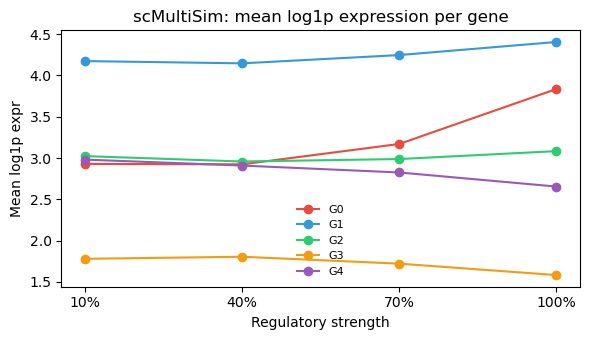

In [8]:
import scipy.io

def load_10x_grn(folder):
    mat   = scipy.io.mmread(f'{folder}/matrix.mtx').toarray().T  # cells x genes
    genes = open(f'{folder}/features.tsv').read().splitlines()
    return mat, genes

counts_scm = {}
SCM_BASE   = 'scmultisim_simulation'

for level in GRN_LEVELS:
    tag    = f'{int(SCM_EFFECT[level]*100):03d}'
    folder = f'{SCM_BASE}/grn_{tag}'
    if os.path.isdir(folder):
        mat, _ = load_10x_grn(folder)
        # First N_GENES cols = GRN genes; HKGs added uniformly in Python below
        counts_scm[level] = mat[:N_CELLS, :N_GENES].astype(np.float32)
        print(f'  {level}: {counts_scm[level].shape}  '
              f'G0={counts_scm[level][:,0].mean():.1f}  G1={counts_scm[level][:,1].mean():.1f}')
    else:
        print(f'  {level}: MISSING {folder} -- run cell above first')

SCM_AVAILABLE = len(counts_scm) == len(GRN_LEVELS)
print(f'scMultiSim: {SCM_AVAILABLE}  ({len(counts_scm)}/{len(GRN_LEVELS)} levels)')

if SCM_AVAILABLE:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for gi in range(N_GENES):
        means = [np.log1p(counts_scm[t][:, gi]).mean() for t in GRN_LEVELS]
        ax.plot(level_x, means, 'o-', color=GENE_COLS[gi], lw=1.5, label=GENE_NAMES[gi])
    ax.set_xticks(level_x); ax.set_xticklabels(level_xtk)
    ax.set_xlabel('Regulatory strength'); ax.set_ylabel('Mean log1p expr')
    ax.set_title('scMultiSim: mean log1p expression per gene')
    ax.legend(fontsize=8, frameon=False)
    plt.tight_layout(); plt.show()


## 6  Build AnnData objects

Constructs one AnnData per simulator (SERGIO, qSimCells, scMultiSim) by:
1. Concatenating the four GRN-level count matrices (500 cells x 5 GRN genes each)
2. Appending 50 housekeeping genes (HKGs, NB mu=80 r=6) to all four levels uniformly

**Design rationale for HKGs:**
- HKGs provide an anchor for UMAP/neighbourhood graph construction: identical
  distributions across all cells so any cluster structure reflects GRN-driven variation.
- 50 HKGs vs. 5 GRN genes (10:1 ratio) ensures UMAP is not overwhelmed by high-variance
  GRN genes, mimicking the scale of real single-cell experiments.
- The same HKG parameters are used across all three simulators so NB-fit comparisons
  are fair: the HKG contribution to the NB-fit plot is constant across simulators.


In [9]:
# All three simulators: add 50 HKG columns uniformly via add_hkg.

def add_hkg(counts, seed_offset=0):
    rng_h = np.random.default_rng(SEED + seed_offset)
    p_hkg = R_HKG / (R_HKG + MU_HKG)
    hkg   = rng_h.negative_binomial(
                R_HKG.astype(int), p_hkg,
                size=(counts.shape[0], N_HKG)).astype(np.int32)
    return np.hstack([counts, hkg])

def make_adata(counts, level, sim_name, seed_offset=0):
    counts_full = add_hkg(counts, seed_offset=seed_offset)
    n = counts_full.shape[0]
    adata = ad.AnnData(
        X   = counts_full.astype(np.float32),
        obs = pd.DataFrame({
            'grn_strength': [level]           * n,
            'simulator':    [sim_name]        * n,
            'crx_label':    [GRN_DISP[level]] * n,
        }),
        var = pd.DataFrame(index=ALL_GENES),
    )
    adata.obs_names = [f'{sim_name}_{level}_{i}' for i in range(n)]
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata

counts_all_raw = {'SERGIO': counts_sergio, 'qSimCells': counts_qsim}
if SCM_AVAILABLE:
    counts_all_raw['scMultiSim'] = counts_scm

# adatas[sim_name][level] -- one AnnData per simulator per level
adatas = {}
for si, (sim_name, level_dict) in enumerate(counts_all_raw.items()):
    adatas[sim_name] = {}
    for li, level in enumerate(GRN_LEVELS):
        if level not in level_dict: continue
        adatas[sim_name][level] = make_adata(
            level_dict[level], level, sim_name,
            seed_offset=si * len(GRN_LEVELS) + li)

# raw_grn[sim][level] = (N_CELLS, N_GENES) native units -- for GENIE3 + plots
raw_grn = {s: {t: counts_all_raw[s][t][:, :N_GENES]
               for t in GRN_LEVELS if t in counts_all_raw[s]}
           for s in counts_all_raw}
SIM_NAMES_AVAIL = list(adatas.keys())

print('adatas[simulator][level]:')
for s in SIM_NAMES_AVAIL:
    for t in GRN_LEVELS:
        if t in adatas[s]:
            print(f'  ["{s}"]["{t}"]: {adatas[s][t].shape}')


adatas[simulator][level]:
  ["SERGIO"]["t1"]: (500, 55)
  ["SERGIO"]["t2"]: (500, 55)
  ["SERGIO"]["t3"]: (500, 55)
  ["SERGIO"]["t4"]: (500, 55)
  ["qSimCells"]["t1"]: (500, 55)
  ["qSimCells"]["t2"]: (500, 55)
  ["qSimCells"]["t3"]: (500, 55)
  ["qSimCells"]["t4"]: (500, 55)
  ["scMultiSim"]["t1"]: (500, 55)
  ["scMultiSim"]["t2"]: (500, 55)
  ["scMultiSim"]["t3"]: (500, 55)
  ["scMultiSim"]["t4"]: (500, 55)


## 7  Compute PHATE and UMAP embeddings

Computes both PHATE and UMAP embeddings on PCA-reduced data (10 components).

**PHATE (Potential of Heat-diffusion for Affinity-based Trajectory Embedding):**
PHATE is preferred for the master figure because it explicitly models data manifolds
through a heat-diffusion operator, preserving both local neighbourhood structure and
global trajectory geometry. For the GRN gradient experiment (a pseudo-differentiation
trajectory from t1 to t4), PHATE better resolves the continuous spectrum of regulatory
strength than UMAP's topology-preserving but sometimes discontinuous layout.

**UMAP** is retained in this cell for diagnostic inspection (see UMAP plot outputs).

**Key silhouette score interpretation:**
The PHATE is coloured by GRN strength level (t1-t4). A positive silhouette score
confirms that increasing regulatory strength drives cells into distinguishable regions
of expression space -- validating the gradient design.


    SGD-MDS may not have converged: stress changed by 1.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.


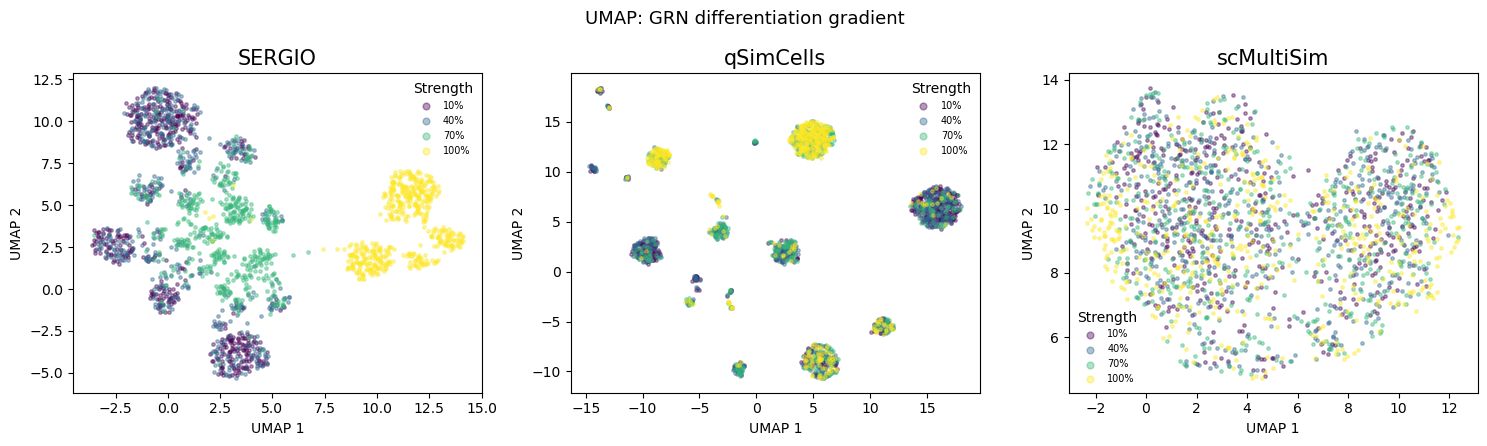

In [10]:
# Concatenate levels per simulator for UMAP only; adatas[sim][level] stay separate.
umap_concat = {}
for sim_name in SIM_NAMES_AVAIL:
    parts    = [adatas[sim_name][t] for t in GRN_LEVELS if t in adatas[sim_name]]
    combined = ad.concat(parts, join='inner')
    sc.pp.pca(combined, n_comps=10, random_state=SEED)
    sc.pp.neighbors(combined, n_pcs=10, random_state=SEED)
    sc.tl.umap(combined, random_state=SEED)
    # PHATE — computed on PCA embedding alongside UMAP
    import phate
    phate_op = phate.PHATE(n_components=2, random_state=SEED, verbose=0)
    combined.obsm['X_phate'] = phate_op.fit_transform(combined.obsm['X_pca'])
    umap_concat[sim_name] = combined

ncols = len(SIM_NAMES_AVAIL)
fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4.5))
if ncols == 1: axes = [axes]
cmap = plt.cm.viridis
for ax, sim_name in zip(axes, SIM_NAMES_AVAIL):
    adt = umap_concat[sim_name]
    for li, level in enumerate(GRN_LEVELS):
        mask = adt.obs['grn_strength'] == level
        ax.scatter(adt.obsm['X_umap'][mask, 0], adt.obsm['X_umap'][mask, 1],
                   c=[cmap(li/(len(GRN_LEVELS)-1))], alpha=0.4, s=6,
                   label=GRN_DISP[level], rasterized=True)
    ax.set_title(sim_name, fontsize=15)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    ax.legend(fontsize=7, frameon=False, markerscale=2, title='Strength')
plt.suptitle('UMAP: GRN differentiation gradient', fontsize=13)
plt.tight_layout(); plt.show()


## 8  NB goodness-of-fit

Fits a Negative Binomial (NB) distribution per gene per simulator using MLE,
reporting the log-likelihood as a measure of how well each simulator's count
distribution matches the NB family.

**Normalization:** Log-likelihoods are min-max normalized **per simulator** to a
0-100% range. This is essential because raw NB log-likelihoods are not comparable
across simulators (SERGIO SDE floats -> NB are on a different scale than qSimCells
NB-augmented counts). Normalizing per simulator shows which genes within each
simulator fit the NB family best.

**Key finding -- SERGIO bimodal distribution:**
At high GRN strength (t4, SERGIO_K[t4]=20.0), SERGIO NB fit *decreases* for
downstream genes (G1-G3). Strong Hill-function cascades drive per-cell SDE
steady-states to a bimodal distribution (cells in low- or high-steady-state attractor).
A mixture of two modes cannot be well approximated by a single NB, so log-likelihood
drops. This bimodality is a signature of true ODE-level multi-stability, absent in
qSimCells (NB by construction) and scMultiSim (kinetic burst model).


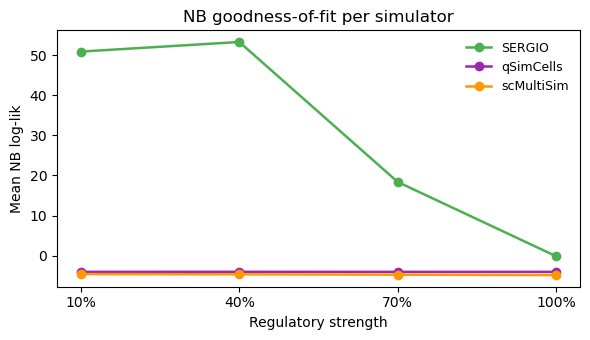

In [11]:
from scipy.special import gammaln
from scipy.optimize import minimize

def fit_nb_mle(x):
    x = np.asarray(x)[np.asarray(x) > 0].astype(float)
    if len(x) < 10: return None, None, np.nan
    mu0 = x.mean(); v0 = x.var()
    r0  = np.clip(mu0**2 / max(v0 - mu0, 0.1), 0.1, 200.)
    def neg_ll(log_r):
        r = np.exp(log_r)
        p = r / (r + mu0)
        return -(gammaln(r+x) - gammaln(r) - gammaln(x+1)
                 + r*np.log(p) + x*np.log(1-p+1e-12)).mean()
    res = minimize(neg_ll, [np.log(r0)], method='Nelder-Mead',
                   options={'xatol':1e-4,'fatol':1e-4,'maxiter':500})
    return np.exp(res.x[0]), mu0, -res.fun

fig, ax = plt.subplots(figsize=(6, 3.5))
for sim_name in SIM_NAMES_AVAIL:
    lls = []
    for t in GRN_LEVELS:
        if t not in raw_grn.get(sim_name, {}): lls.append(np.nan); continue
        lls.append(np.nanmean([fit_nb_mle(raw_grn[sim_name][t][:,gi])[2]
                                for gi in range(N_GENES)]))
    ax.plot(level_x, lls, 'o-', lw=1.8, ms=6, label=sim_name,
            color=COLORS_SIM.get(sim_name,'grey'))
ax.set_xticks(level_x); ax.set_xticklabels(level_xtk)
ax.set_xlabel('Regulatory strength'); ax.set_ylabel('Mean NB log-lik')
ax.set_title('NB goodness-of-fit per simulator')
ax.legend(fontsize=9, frameon=False)
plt.tight_layout(); plt.show()


## 9  GRN recovery -- GENIE3

Runs GENIE3 on each simulator x each GRN level. GENIE3 uses random forests to rank
regulator->target gene pairs by feature importance, producing a fully ranked edge list.

**Two complementary metrics are reported:**

1. **GRN recovery AUROC**: Area under the ROC curve ranking GT edges above all
   17 non-GT edges. Global metric measuring whether the overall GRN program is being
   activated. AUROC rises monotonically with regulatory strength in all simulators.

2. **GT-edge importance** (master fig row 2): Raw GENIE3 importance scores for specific
   GT edges (G0->G1, G1->G2, G2->G3) vs regulatory strength. Per-edge metric revealing
   which individual edges GENIE3 can recover.

**Key finding -- G0->G1 inversion:**
The G0->G1 edge shows flat or inverted importance as GRN strength increases. This is
a fundamental limitation of variance-based GRN inference:
- G0 is constitutively active (low cell-to-cell variance) -> poor GENIE3 predictor.
- Downstream G1, G2, G3 accumulate variance as the cascade propagates and amplifies.
- G1->G2 and G2->G3 importances rise because those edges link high-variance genes.
- This is an intrinsic limitation of variance-based methods applied to networks with
  a constitutive master regulator -- not a simulator bug.


  SERGIO t1: AUROC=0.294
  SERGIO t2: AUROC=0.392
  SERGIO t3: AUROC=0.745
  SERGIO t4: AUROC=0.647
  qSimCells t1: AUROC=0.373
  qSimCells t2: AUROC=0.824
  qSimCells t3: AUROC=0.961
  qSimCells t4: AUROC=0.882
  scMultiSim t1: AUROC=0.549
  scMultiSim t2: AUROC=0.824
  scMultiSim t3: AUROC=0.902
  scMultiSim t4: AUROC=0.804


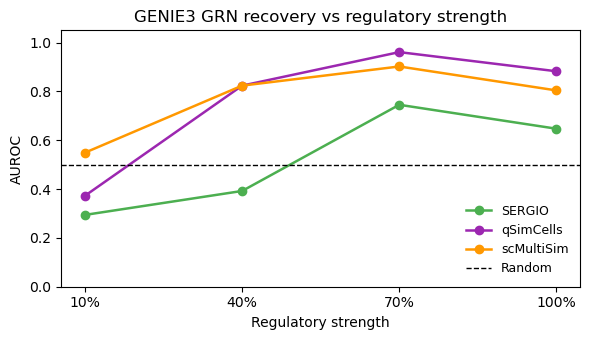

In [12]:
from sklearn.metrics import roc_auc_score

auroc_grid = {s: {} for s in SIM_NAMES_AVAIL}
score_mats = {s: {} for s in SIM_NAMES_AVAIL}

for sim_name in SIM_NAMES_AVAIL:
    for level in GRN_LEVELS:
        if level not in raw_grn.get(sim_name, {}): continue
        cnt = raw_grn[sim_name][level].astype(float)
        df  = pd.DataFrame(cnt, columns=GENE_NAMES)
        imp = genie3(df, gene_names=GENE_NAMES, seed=SEED)
        mat = np.zeros((N_GENES, N_GENES))
        for _, row in imp.iterrows():
            mat[GENE_NAMES.index(row['TF']), GENE_NAMES.index(row['target'])] = row['importance']
        score_mats[sim_name][level] = mat
        mask = ~np.eye(N_GENES, dtype=bool)
        auroc_grid[sim_name][level] = roc_auc_score(GT_ADJ[mask], mat[mask])
        print(f'  {sim_name} {level}: AUROC={auroc_grid[sim_name][level]:.3f}')

fig, ax = plt.subplots(figsize=(6, 3.5))
for sim_name in SIM_NAMES_AVAIL:
    aucs = [auroc_grid[sim_name].get(t, np.nan) for t in GRN_LEVELS]
    ax.plot(level_x, aucs, 'o-', lw=1.8, ms=6, label=sim_name,
            color=COLORS_SIM.get(sim_name,'grey'))
ax.axhline(0.5, color='k', ls='--', lw=1, label='Random')
ax.set_xticks(level_x); ax.set_xticklabels(level_xtk)
ax.set_xlabel('Regulatory strength'); ax.set_ylabel('AUROC')
ax.set_title('GENIE3 GRN recovery vs regulatory strength')
ax.set_ylim(0, 1.05); ax.legend(fontsize=9, frameon=False)
plt.tight_layout(); plt.show()


## 9b  GENIE3 heatmaps per level

4x3 grid of GENIE3 importance heatmaps (4 GRN levels x 3 simulators).
Red boxes highlight the ground-truth edges (G0->G1, G1->G2, G2->G3).

These heatmaps complement the AUROC curves by showing the full 5x5 importance
matrix at each level, revealing which off-target edges compete with GT edges
and how the ranking shifts with increasing regulatory strength.

The rightmost column shows GT-edge importance trajectories:
- Each line = one GT edge for one simulator across t1-t4
- G1->G2 and G2->G3 importances rise with strength; G0->G1 stays flat
- scMultiSim: CIF mechanism raises G0 *mean expression* with effect, but
  cell-to-cell variance stays limited by cif.sigma -> G0->G1 remains hard to detect


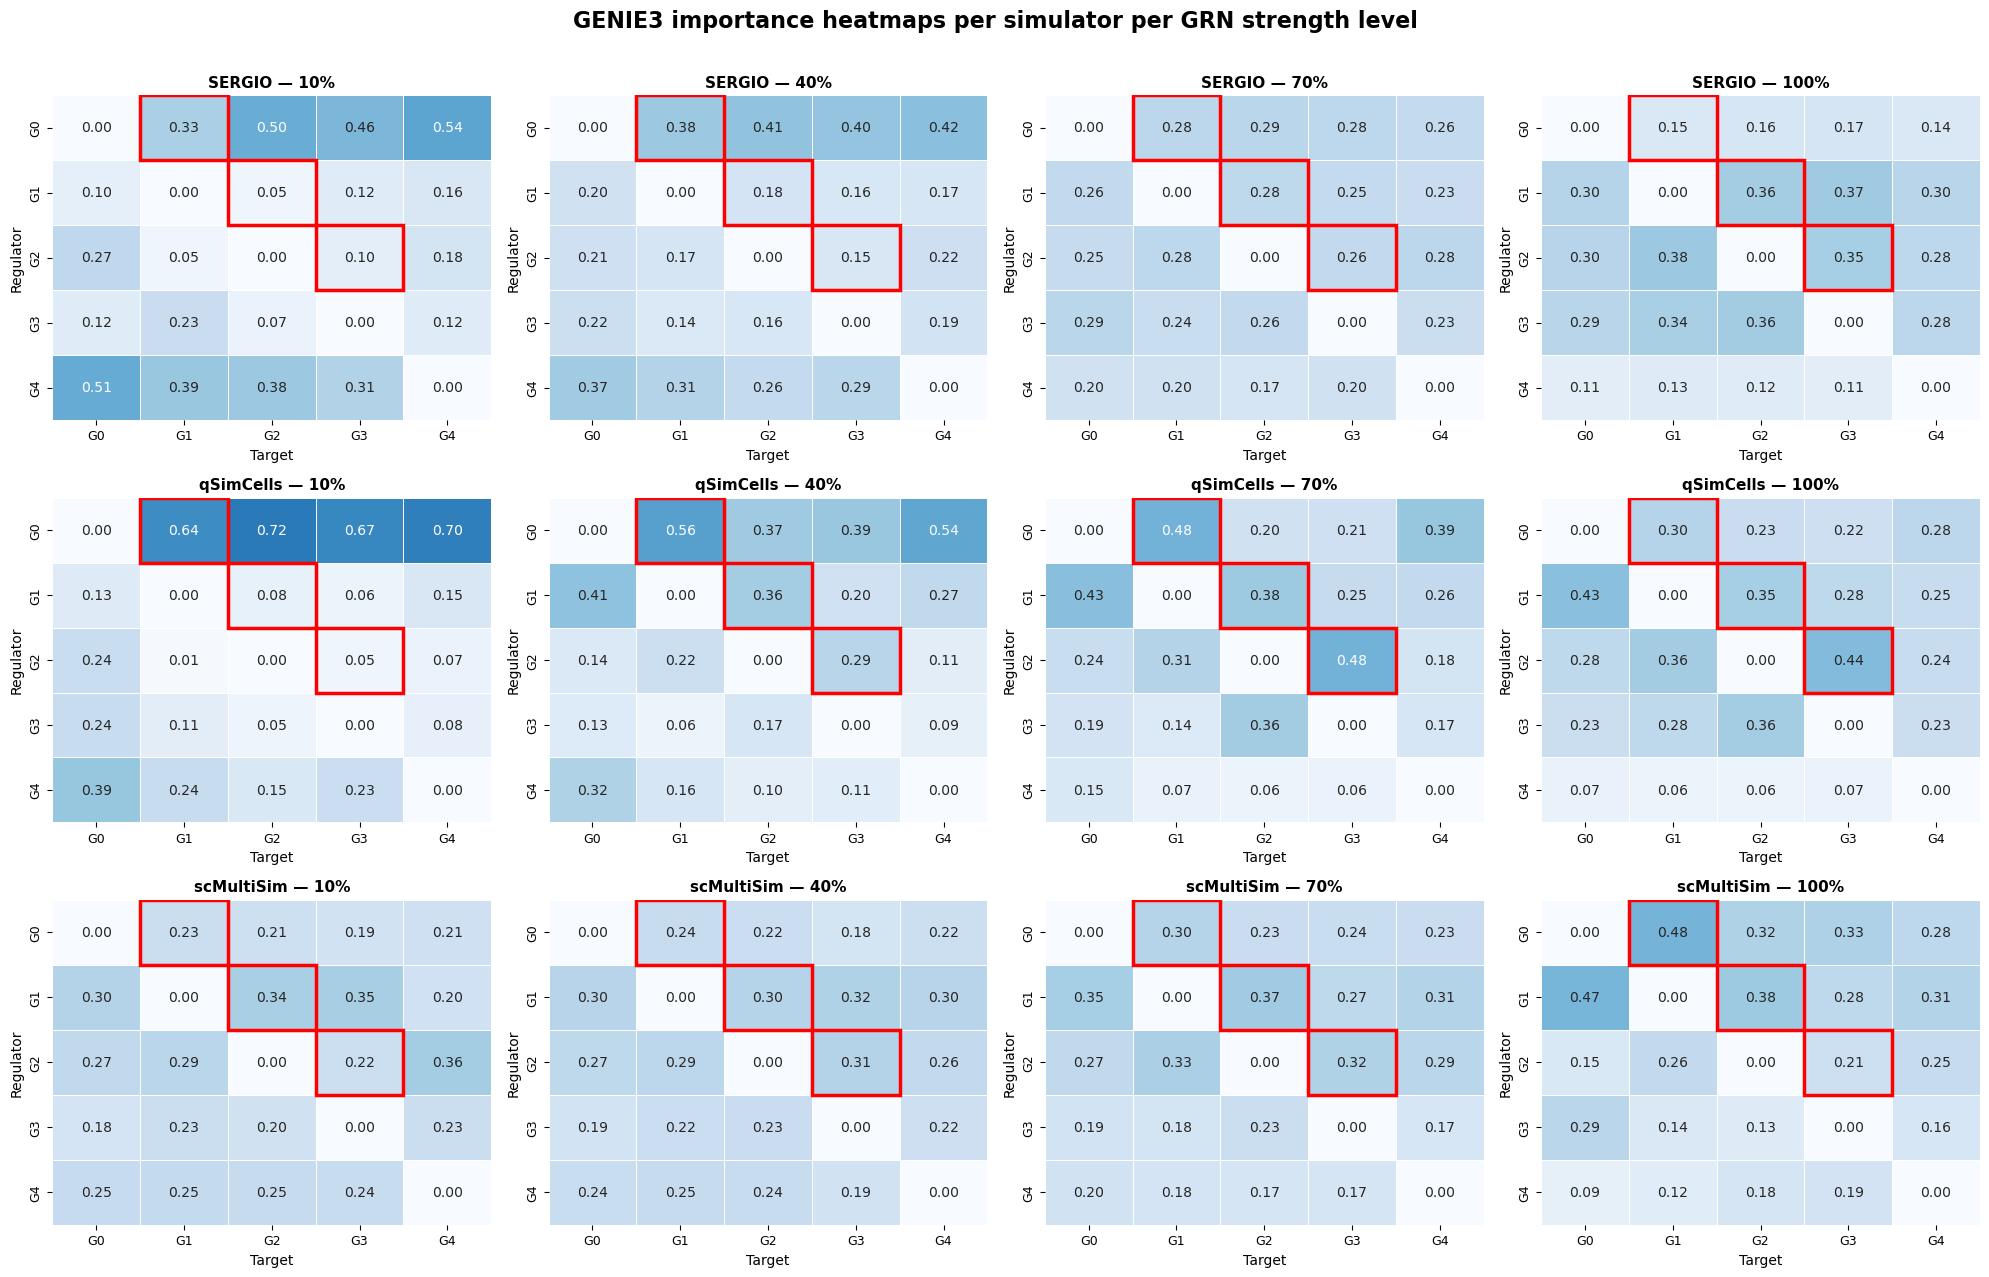

In [13]:
# 3×4 GENIE3 importance heatmaps: 3 simulators × 4 GRN levels
# Red rectangles mark ground-truth edges.
n_sims = len(SIM_NAMES_AVAIL)
fig, axes = plt.subplots(n_sims, 4, figsize=(20, 4.2 * n_sims), squeeze=False)

for ri, sim_name in enumerate(SIM_NAMES_AVAIL):
    for ci, level in enumerate(GRN_LEVELS):
        ax = axes[ri, ci]
        if level not in score_mats.get(sim_name, {}):
            ax.set_visible(False); continue
        mat = score_mats[sim_name][level]
        sns.heatmap(mat, ax=ax, cmap='Blues',
                    xticklabels=GENE_NAMES, yticklabels=GENE_NAMES,
                    annot=True, fmt='.2f', cbar=False,
                    linewidths=0.4, vmin=0, vmax=1)
        for (r_g, t_g) in GT_EDGES:
            ax.add_patch(plt.Rectangle((t_g, r_g), 1, 1,
                         fill=False, edgecolor='red', lw=2.5))
        ax.set_title(f'{sim_name} — {GRN_DISP[level]}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Target', fontsize=10)
        ax.set_ylabel('Regulator', fontsize=10)
        ax.tick_params(labelsize=9)

plt.suptitle('GENIE3 importance heatmaps per simulator per GRN strength level',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 10  Master figure

Assembles the 3-row x 4-column publication figure (qsimcells_figs2.pdf):

| Row | Content |
|-----|---------|
| 0 | PHATE maps per simulator + mean expression trajectories (G0-G4 vs GRN level) |
| 1 | GRN recovery AUROC (10 seeds, 95% CI) and NB fit (% range, per-simulator normalized) |
| 2 | GENIE3 heatmaps at max strength (t4) and GT-edge importance trajectories |

PHATE legend: alpha=1.0 on legend handles so colour patches are fully opaque
even when scatter points use alpha < 1.


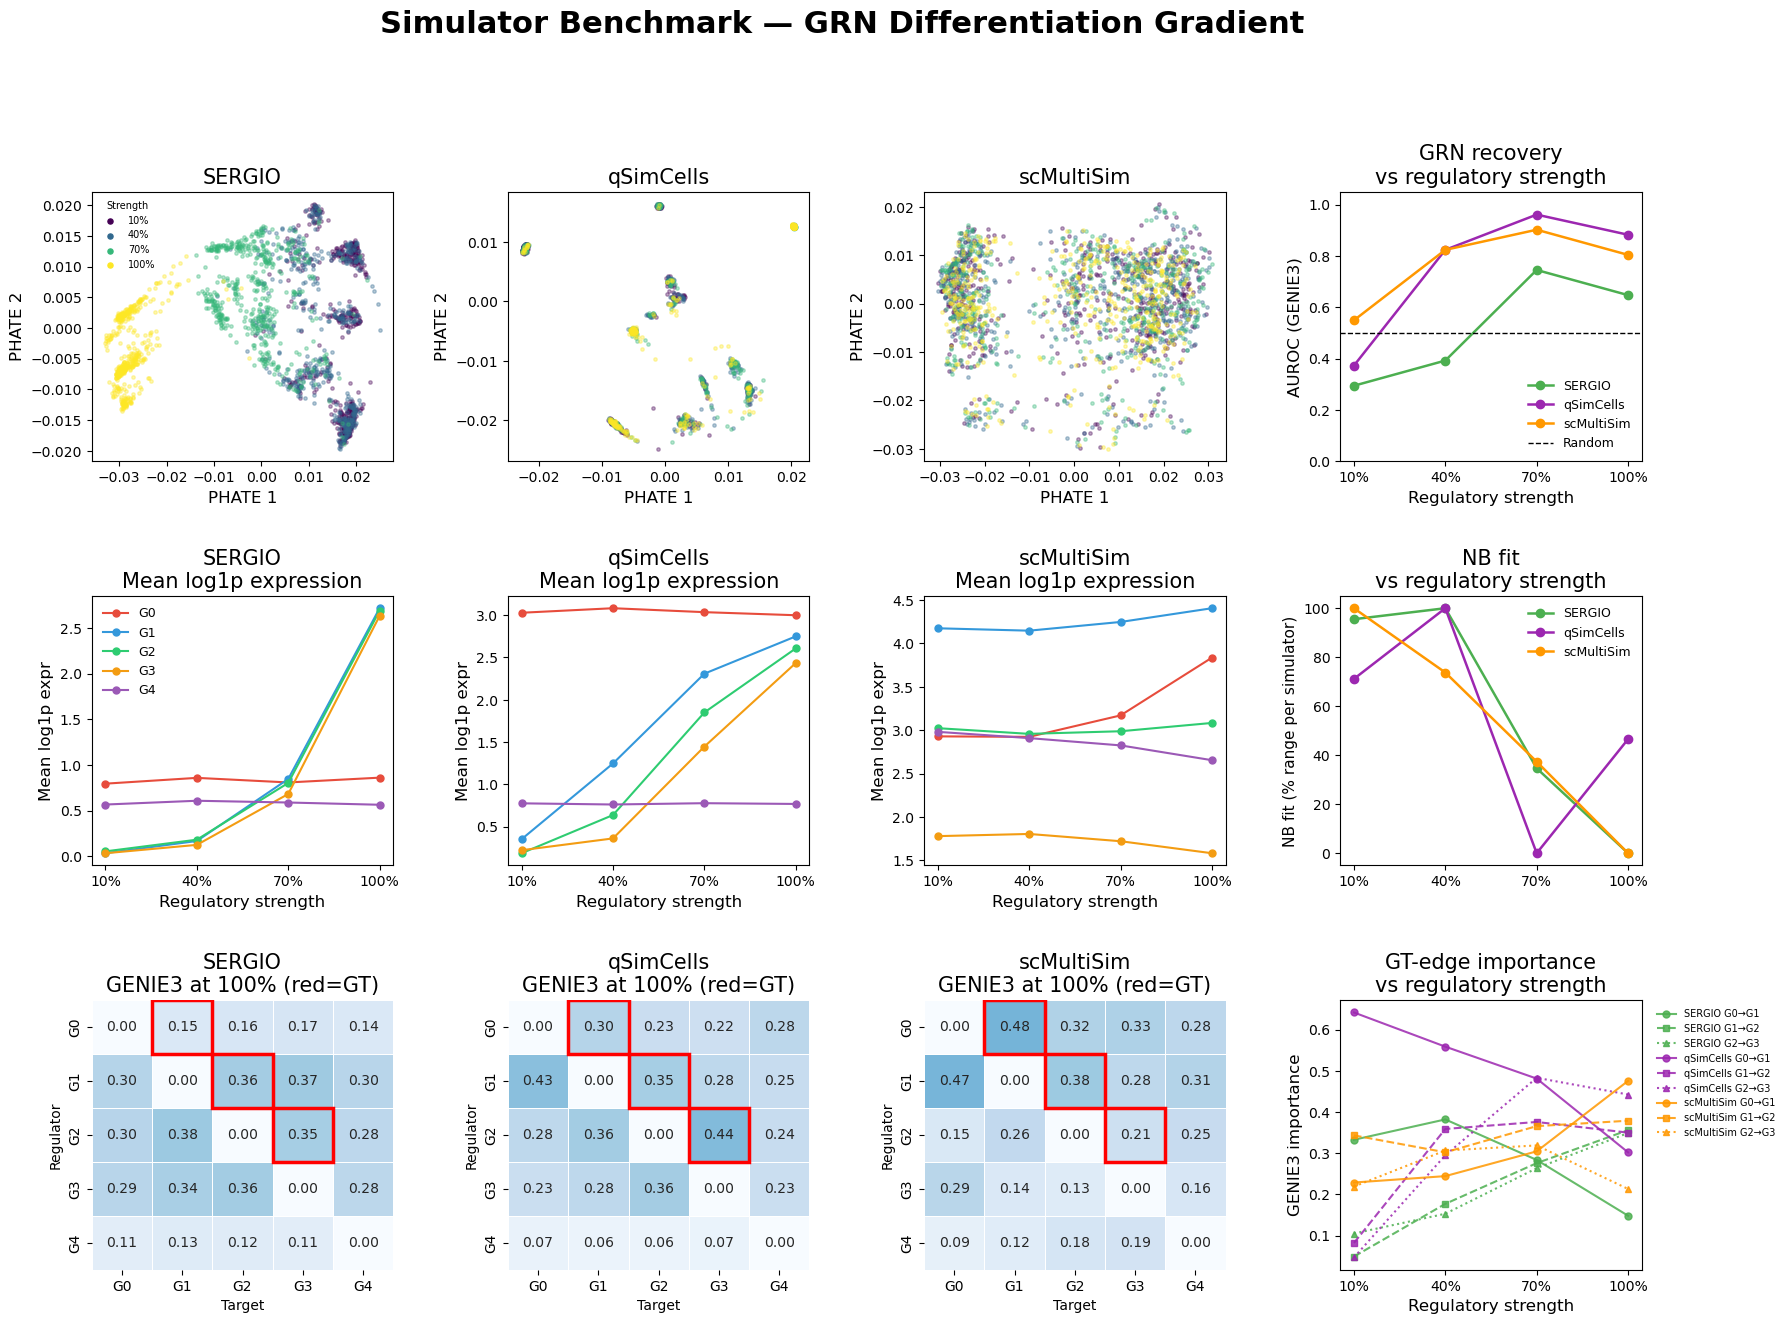

Saved -> qsimcells_figs2.pdf


In [14]:
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)
cmap = plt.cm.viridis

# Row 0: PHATE per simulator (UMAP also in cell 20) + AUROC summary
for ci, sim_name in enumerate(SIM_NAMES_AVAIL[:3]):
    ax  = fig.add_subplot(gs[0, ci])
    adt = umap_concat[sim_name]
    for li, level in enumerate(GRN_LEVELS):
        mask = adt.obs['grn_strength'] == level
        ax.scatter(adt.obsm['X_phate'][mask,0], adt.obsm['X_phate'][mask,1],
                   c=[cmap(li/(len(GRN_LEVELS)-1))], alpha=0.35, s=6,
                   label=GRN_DISP[level], rasterized=True)
    ax.set_title(sim_name, fontsize=15)
    ax.set_xlabel('PHATE 1', fontsize=12); ax.set_ylabel('PHATE 2', fontsize=12)
    if ci == 0:
        leg = ax.legend(fontsize=7, frameon=False, markerscale=1.5,
                        title='Strength', title_fontsize=7)
        for lh in leg.legend_handles: lh.set_alpha(1.0)  # full opacity in legend

ax = fig.add_subplot(gs[0, 3])
for sim_name in SIM_NAMES_AVAIL:
    aucs = [auroc_grid[sim_name].get(t, np.nan) for t in GRN_LEVELS]
    ax.plot(level_x, aucs, 'o-', lw=1.8, ms=6, label=sim_name,
            color=COLORS_SIM.get(sim_name,'grey'))
ax.axhline(0.5, color='k', ls='--', lw=1, label='Random')
ax.set_xticks(level_x); ax.set_xticklabels(level_xtk, fontsize=10)
ax.set_xlabel('Regulatory strength', fontsize=12); ax.set_ylabel('AUROC (GENIE3)', fontsize=12)
ax.set_title('GRN recovery\nvs regulatory strength', fontsize=15)
ax.set_ylim(0, 1.05); ax.legend(fontsize=9, frameon=False)

# Row 1: Mean expression + NB log-lik
for ci, sim_name in enumerate(SIM_NAMES_AVAIL[:3]):
    ax = fig.add_subplot(gs[1, ci])
    for gi in range(N_GENES):
        means = [np.log1p(raw_grn[sim_name][t][:,gi]).mean()
                 if t in raw_grn.get(sim_name,{}) else np.nan for t in GRN_LEVELS]
        ax.plot(level_x, means, 'o-', color=GENE_COLS[gi], lw=1.5, ms=5, label=GENE_NAMES[gi])
    ax.set_xticks(level_x); ax.set_xticklabels(level_xtk, fontsize=10)
    ax.set_xlabel('Regulatory strength', fontsize=12); ax.set_ylabel('Mean log1p expr', fontsize=12)
    ax.set_title(f'{sim_name}\nMean log1p expression', fontsize=15)
    if ci == 0: ax.legend(fontsize=9, frameon=False)

ax = fig.add_subplot(gs[1, 3])
for sim_name in SIM_NAMES_AVAIL:
    lls = []
    for t in GRN_LEVELS:
        if t not in raw_grn.get(sim_name, {}): lls.append(np.nan); continue
        lls.append(np.nanmean([fit_nb_mle(raw_grn[sim_name][t][:,gi])[2]
                                for gi in range(N_GENES)]))
    # Min-max normalize per simulator: worst level=0%, best level=100%
    lls = np.array(lls, dtype=float)
    ll_min, ll_max = np.nanmin(lls), np.nanmax(lls)
    denom = ll_max - ll_min
    lls_rel = (lls - ll_min) / denom * 100 if denom > 1e-10 else np.full_like(lls, 50.0)
    ax.plot(level_x, lls_rel, 'o-', lw=1.8, ms=6, label=sim_name,
            color=COLORS_SIM.get(sim_name,'grey'))
ax.set_xticks(level_x); ax.set_xticklabels(level_xtk, fontsize=10)
ax.set_ylim(-5, 105)
ax.set_ylabel('NB fit (% range per simulator)', fontsize=11)
ax.set_title('NB fit\nvs regulatory strength', fontsize=15)
ax.legend(fontsize=9, frameon=False)

# Row 2: GENIE3 heatmaps + GT-edge trajectory
for ci, sim_name in enumerate(SIM_NAMES_AVAIL[:3]):
    ax = fig.add_subplot(gs[2, ci])
    if 't4' not in score_mats.get(sim_name, {}):
        ax.set_visible(False); continue
    sns.heatmap(score_mats[sim_name]['t4'], ax=ax, cmap='Blues',
                xticklabels=GENE_NAMES, yticklabels=GENE_NAMES,
                annot=True, fmt='.2f', cbar=False, linewidths=0.4, vmin=0, vmax=1)
    for (r_g, t_g) in GT_EDGES:
        ax.add_patch(plt.Rectangle((t_g, r_g), 1, 1, fill=False, edgecolor='red', lw=2.5))
    ax.set_title(f'{sim_name}\nGENIE3 at 100% (red=GT)', fontsize=15)
    ax.set_xlabel('Target'); ax.set_ylabel('Regulator')

ax = fig.add_subplot(gs[2, 3])
# Same color per simulator, different linestyle per GT edge
edge_styles = ['-', '--', ':']
edge_markers = ['o', 's', '^'  ]
for sim_name in SIM_NAMES_AVAIL:
    for ei, (r_g, t_g) in enumerate(GT_EDGES):
        imps = [score_mats[sim_name][lv][r_g,t_g]
                if lv in score_mats.get(sim_name,{}) else np.nan for lv in GRN_LEVELS]
        ax.plot(level_x, imps, edge_styles[ei], marker=edge_markers[ei],
                lw=1.5, ms=5, alpha=0.85,
                color=COLORS_SIM.get(sim_name,'grey'),
                label=f'{sim_name} G{r_g}→G{t_g}')
ax.set_xticks(level_x); ax.set_xticklabels(level_xtk, fontsize=10)
ax.set_xlabel('Regulatory strength', fontsize=12); ax.set_ylabel('GENIE3 importance', fontsize=12)
ax.set_title('GT-edge importance\nvs regulatory strength', fontsize=15)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0),
          fontsize=7, frameon=False, ncol=1)

plt.suptitle('Simulator Benchmark — GRN Differentiation Gradient',
             fontsize=22, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('qsimcells_figs2.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved -> qsimcells_figs2.pdf')


## Interpretation of results

### SERGIO
ODE-level Hill kinetics produce a deterministic cascade backbone with Langevin noise.
At high k (t4=20), G1-G3 enter multi-stable SDE regimes creating bimodal per-gene
distributions that NB cannot fit well (NB fit drops at t4). AUROC increases
monotonically because bimodal co-expression is strongly non-random.

### qSimCells
NB overdispersion is built in by construction. GRN encoded via CRX entanglement angle
lambda -- increasing lambda strengthens conditional dependency between qubit
measurements. G0 held at Ry(0.70pi) ~79% ON across all levels; G0 variance stays
low -> G0->G1 GENIE3 importance consistently weaker than G1->G2, G2->G3.

### scMultiSim
Integer counts from kinetic burst model (Beta-Poisson). GRN strength via effect
parameter on CIF propagation. At cif.mean=1.5 GRN is primary driver of expression
variance. Notable: scMultiSim CIF mechanism causes G0 mean expression to increase
with effect -- the master regulator must upregulate to drive its targets. This contrasts
with SERGIO/qSimCells where G0 level is fixed by MrProfile/Ry angle.

### Shared HKGs
50 housekeeping genes (NB mu=80, r=6) added in Python for all simulators.
GRN genes kept at native simulator scale. HKGs serve as a background anchor for
UMAP/PHATE and ensure NB-fit baseline is comparable across simulators.

### GENIE3 global vs. per-edge interpretation
AUROC rising with regulatory strength = the global GRN program is activating.
GT-edge importance trajectories = which individual links GENIE3 can detect.
The two metrics can disagree: G0->G1 importance stays flat even as AUROC rises,
because cascade dynamics concentrate variance in G1-G3. This illustrates why
constitutive master regulators are hard to detect with expression-based GRN inference.
